In [178]:
import numpy as np
import pandas as pd 

In [179]:
np.random.seed(30)
n=6500

features :
traffic_density, rainfall, road_condition,signal,speed, intersections,visibility,pedestrians,time_of_day,vehicle_type 


for numerical features

In [180]:
traffic_density = np.random.randint(10, 1000, n)
rainfall = np.random.uniform(0, 500, n)
road_condition= np.random.randint(1,6,n)
signal=np.random.randint(20,180,n)
speed=np.random.randint(20,100,n)
intersection=np.random.randint(0,6,n)
visibility=np.random.randint(30,100,n)
pedestrians=np.random.randint(0,300,n)

for categorical features

In [181]:
time_of_day = np.random.choice(['early morning','morning', 'afternoon', 'evening', 'night','mid night'], n)
vehicle_type = np.random.choice(['car', 'cars+bikes', 'cars+bus', 'heavy vehicles', 'mixed'], n)

In [182]:
time_risk = {
    'early morning':0.1,
    'morning':0.7,
    'afternoon':0.3,
    'evening':0.9,
    'night':0.5,
    'mid night':0.4
}
vehicle_risk = {
    'car':0.2,
    'cars+bikes':0.6,
    'cars+bus':0.7,
    'heavy vehicles':0.8,
    'mixed':1.0
}

In [183]:
risk_score = (

    0.002 * traffic_density +

    0.02 * speed +

    -0.6 * road_condition +

    0.008 * rainfall +

    0.003 * signal +

    0.15 * intersection +

    -0.01 * visibility +

    0.006 * pedestrians +

    np.vectorize(time_risk.get)(time_of_day) +

    np.vectorize(vehicle_risk.get)(vehicle_type)

)

In [184]:
probability = 1 / (1 + np.exp(-(risk_score - risk_score.mean())))

In [185]:
crash_occurs = np.random.binomial(1, probability)

In [186]:
pd.Series(crash_occurs).value_counts(normalize=True)

0    0.502462
1    0.497538
Name: proportion, dtype: float64

In [187]:
df = pd.DataFrame({

    'traffic_density': traffic_density,
    'rainfall': rainfall,
    'road_condition': road_condition,
    'signal': signal,
    'speed': speed,
    'intersection': intersection,
    'visibility': visibility,
    'pedestrians': pedestrians,
    'time_of_day': time_of_day,
    'vehicle_type': vehicle_type,
    'crash_occurs': crash_occurs

})

In [188]:
print(df.head())
print(df.shape)


   traffic_density    rainfall  road_condition  signal  speed  intersection  \
0              815   20.242753               4      28     37             0   
1              431  399.646483               1      22     53             4   
2              951  130.394657               2     146     82             3   
3              823  161.379554               2      93     32             0   
4              510  117.816142               1      56     34             1   

   visibility  pedestrians    time_of_day    vehicle_type  crash_occurs  
0          85          268  early morning  heavy vehicles             0  
1          78          235      mid night             car             0  
2          65          124      afternoon        cars+bus             0  
3          60          272      afternoon             car             1  
4          59           86          night      cars+bikes             0  
(6500, 11)


In [189]:
df.isnull().sum()
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6500 entries, 0 to 6499
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   traffic_density  6500 non-null   int32  
 1   rainfall         6500 non-null   float64
 2   road_condition   6500 non-null   int32  
 3   signal           6500 non-null   int32  
 4   speed            6500 non-null   int32  
 5   intersection     6500 non-null   int32  
 6   visibility       6500 non-null   int32  
 7   pedestrians      6500 non-null   int32  
 8   time_of_day      6500 non-null   object 
 9   vehicle_type     6500 non-null   object 
 10  crash_occurs     6500 non-null   int32  
dtypes: float64(1), int32(8), object(2)
memory usage: 355.6+ KB
None


In [190]:
df.isnull().sum()

traffic_density    0
rainfall           0
road_condition     0
signal             0
speed              0
intersection       0
visibility         0
pedestrians        0
time_of_day        0
vehicle_type       0
crash_occurs       0
dtype: int64

In [191]:
df_encoded = pd.get_dummies(
    df,
    columns=['time_of_day', 'vehicle_type'],
    drop_first=True
)

In [192]:
print(df_encoded.head())
print(df_encoded.shape)


   traffic_density    rainfall  road_condition  signal  speed  intersection  \
0              815   20.242753               4      28     37             0   
1              431  399.646483               1      22     53             4   
2              951  130.394657               2     146     82             3   
3              823  161.379554               2      93     32             0   
4              510  117.816142               1      56     34             1   

   visibility  pedestrians  crash_occurs  time_of_day_early morning  \
0          85          268             0                       True   
1          78          235             0                      False   
2          65          124             0                      False   
3          60          272             1                      False   
4          59           86             0                      False   

   time_of_day_evening  time_of_day_mid night  time_of_day_morning  \
0                False      

In [193]:
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [194]:
df_encoded.dtypes

traffic_density                  int32
rainfall                       float64
road_condition                   int32
signal                           int32
speed                            int32
intersection                     int32
visibility                       int32
pedestrians                      int32
crash_occurs                     int32
time_of_day_early morning        int64
time_of_day_evening              int64
time_of_day_mid night            int64
time_of_day_morning              int64
time_of_day_night                int64
vehicle_type_cars+bikes          int64
vehicle_type_cars+bus            int64
vehicle_type_heavy vehicles      int64
vehicle_type_mixed               int64
dtype: object

In [ ]:
stats = pd.DataFrame({
    'Mean': df.select_dtypes(include=['int64','int32','float64']).mean(),
    'Variance': df.select_dtypes(include=['int64','int32','float64']).var()
})

print(stats)

                       Mean      Variance
traffic_density  499.488923  82635.456255
rainfall         249.288670  21062.912963
road_condition     3.040154      2.037009
signal            98.311846   2155.568993
speed             59.557846    530.543045
intersection       2.510308      2.883568
visibility        64.631385    413.350177
pedestrians      147.996308   7434.618851
crash_occurs       0.497538      0.250032


In [195]:
X = df_encoded.drop('crash_occurs', axis=1)

y = df_encoded['crash_occurs']

In [196]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [197]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

logistic regression

In [198]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [199]:
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:,1]

In [200]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

tn, fp, fn, tp = cm.ravel()

print("TN =", tn)
print("FP =", fp)
print("FN =", fn)
print("TP =", tp)

[[505 148]
 [141 506]]
TN = 505
FP = 148
FN = 141
TP = 506


metrics


In [201]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7776923076923077
Precision: 0.7737003058103975
Recall   : 0.7820710973724884
F1 Score : 0.7778631821675634


In [202]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC =", auc)

ROC-AUC = 0.8571377851835897


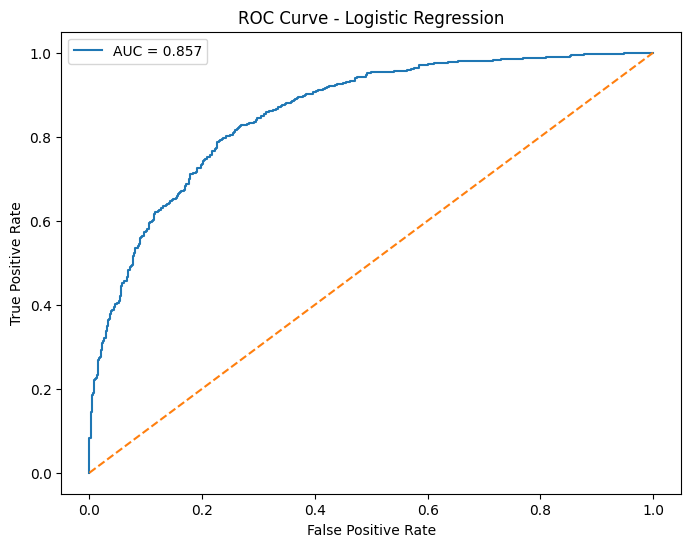

In [203]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [204]:

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_[0]
})

coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])

coefficients.sort_values(
    by='Odds_Ratio',
    ascending=False,
    inplace=True
)

coefficients

,Feature,Coefficient,Odds_Ratio
1,rainfall,1.192246,3.294473
0,traffic_density,0.604389,1.830133
7,pedestrians,0.594342,1.811837
4,speed,0.402646,1.495777
16,vehicle_type_mixed,0.319337,1.376215
5,intersection,0.299142,1.348702
9,time_of_day_evening,0.229089,1.257453
14,vehicle_type_cars+bus,0.222156,1.248766
15,vehicle_type_heavy vehicles,0.203245,1.225372
13,vehicle_type_cars+bikes,0.162886,1.176902


In [205]:
coefficients[['Feature','Odds_Ratio']].round(3)

,Feature,Odds_Ratio
1,rainfall,3.294
0,traffic_density,1.830
7,pedestrians,1.812
4,speed,1.496
16,vehicle_type_mixed,1.376
5,intersection,1.349
9,time_of_day_evening,1.257
14,vehicle_type_cars+bus,1.249
15,vehicle_type_heavy vehicles,1.225
13,vehicle_type_cars+bikes,1.177


In [206]:
coefficients.to_csv(
    "logistic_odds_ratios.csv",
    index=False
)

xgboost 

In [207]:
import xgboost
from xgboost import XGBClassifier


In [208]:

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [209]:
xgb_pred = xgb.predict(X_test)

xgb_prob = xgb.predict_proba(X_test)[:,1]

metrics

In [210]:

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7630769230769231
Precision: 0.75642965204236
Recall   : 0.7727975270479135
F1 Score : 0.764525993883792
ROC-AUC  : 0.8413694019517575


In [211]:

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                        Feature  Importance
2                road_condition    0.169647
1                      rainfall    0.146942
0               traffic_density    0.066177
7                   pedestrians    0.065617
5                  intersection    0.052773
8     time_of_day_early morning    0.052594
4                         speed    0.051278
16           vehicle_type_mixed    0.050526
9           time_of_day_evening    0.050432
6                    visibility    0.042926
3                        signal    0.040112
11          time_of_day_morning    0.036397
15  vehicle_type_heavy vehicles    0.036328
13      vehicle_type_cars+bikes    0.035779
10        time_of_day_mid night    0.035501
14        vehicle_type_cars+bus    0.034541
12            time_of_day_night    0.032431


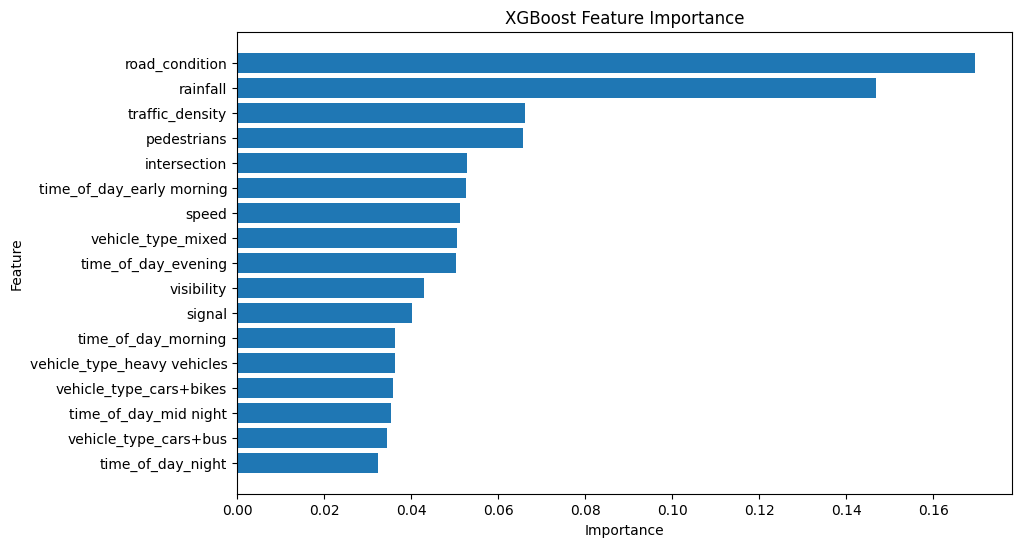

In [212]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [213]:
comparison = pd.DataFrame({

    'Metric':[
        'Accuracy',
        'Precision',
        'Recall',
        'F1',
        'ROC-AUC'
    ],

    'Logistic Regression':[
        0.7669,
        0.7651,
        0.7663,
        0.7657,
        0.8536
    ],

    'XGBoost':[
        0.7646,
        0.7648,
        0.7601,
        0.7624,
        0.8451
    ]
})

comparison

,Metric,Logistic Regression,XGBoost
0,Accuracy,0.7669,0.7646
1,Precision,0.7651,0.7648
2,Recall,0.7663,0.7601
3,F1,0.7657,0.7624
4,ROC-AUC,0.8536,0.8451


threshold comparision

In [214]:
thresholds = np.arange(0.1, 0.91, 0.05)

results = []

for t in thresholds:

    pred = (y_prob >= t).astype(int)

    results.append([
        t,
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ])

threshold_df = pd.DataFrame(
    results,
    columns=[
        'Threshold',
        'Precision',
        'Recall',
        'F1'
    ]
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.562224,0.984544,0.715730
1,0.15,0.601140,0.978362,0.744706
2,0.20,0.630346,0.956723,0.759975
3,0.25,0.661957,0.941267,0.777281
4,0.30,0.682814,0.914992,0.782034
5,0.35,0.705379,0.891808,0.787713
6,0.40,0.721863,0.862442,0.785915
7,0.45,0.744122,0.831530,0.785401
8,0.50,0.773700,0.782071,0.777863
9,0.55,0.789916,0.726430,0.756844


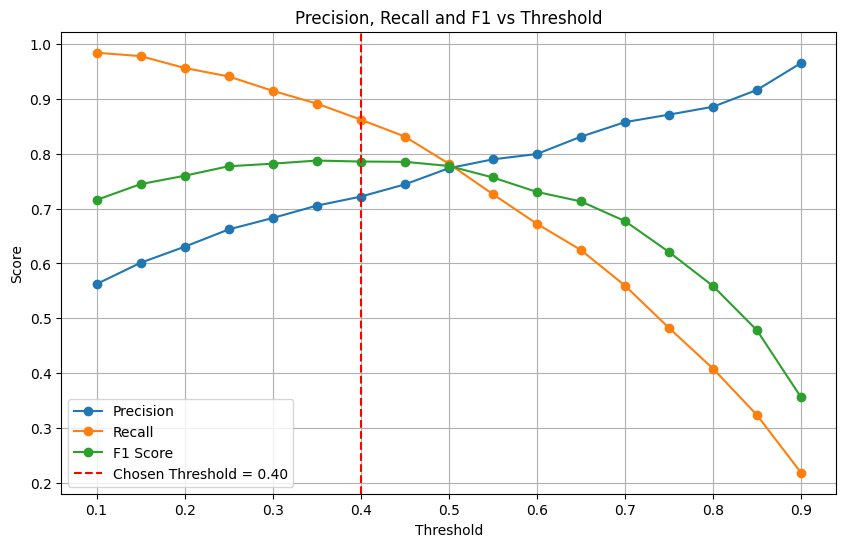

In [215]:
plt.figure(figsize=(10,6))

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Precision'],
    marker='o',
    label='Precision'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['Recall'],
    marker='o',
    label='Recall'
)

plt.plot(
    threshold_df['Threshold'],
    threshold_df['F1'],
    marker='o',
    label='F1 Score'
)

plt.axvline(
    x=0.40,
    color='red',
    linestyle='--',
    label='Chosen Threshold = 0.40'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall and F1 vs Threshold')
plt.legend()
plt.grid(True)

plt.show()

delong test 


In [216]:
from scipy.stats import norm


In [217]:

def compute_midrank(x):
    J = np.argsort(x)
    Z = x[J]
    N = len(x)

    T = np.zeros(N)
    i = 0

    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1

        T[i:j] = 0.5 * (i + j - 1)
        i = j

    T2 = np.empty(N)
    T2[J] = T + 1

    return T2


def fast_delong(predictions_sorted_transposed, label_1_count):

    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m])
    ty = np.empty([k, n])
    tz = np.empty([k, m + n])

    for r in range(k):
        tx[r] = compute_midrank(positive_examples[r])
        ty[r] = compute_midrank(negative_examples[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01)
    sy = np.cov(v10)

    delongcov = sx / m + sy / n

    return aucs, delongcov


def delong_roc_test(y_true, pred1, pred2):

    order = np.argsort(-y_true)

    preds = np.vstack((pred1, pred2))[:, order]

    label_1_count = int(np.sum(y_true))

    aucs, covariance = fast_delong(
        preds,
        label_1_count
    )

    diff = aucs[0] - aucs[1]

    var = (
        covariance[0, 0]
        + covariance[1, 1]
        - 2 * covariance[0, 1]
    )

    z = np.abs(diff) / np.sqrt(var)

    p_value = 2 * (1 - norm.cdf(z))

    return aucs, z, p_value

In [218]:
aucs, z, p = delong_roc_test(
    y_test.values,
    y_prob,
    xgb_prob
)

print("Logistic AUC :", aucs[0])
print("XGBoost AUC  :", aucs[1])
print("Z statistic  :", z)
print("P value      :", p)

Logistic AUC : 0.8571377851835897
XGBoost AUC  : 0.8413694019517575
Z statistic  : 3.828506738113952
P value      : 0.0001289231020460413


logistic regression has an upper hand when compared to xgboost  bcoz the risk score fn is linear and based on tht the synthetic data was made 